# PRF fitting with prfpy
This is a walk through of how you can do fitting with prfpy. It is essentially the same as ```s01_gauss_prfpy.py``` - but you can go through step by step to see how it all works. 

In [3]:
# Import relevant tools
# - select "prf" conda environment for your kernel
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt

from prfpy.stimulus import PRFStimulus2D
from prfpy.model import Iso2DGaussianModel
from prfpy.fit import Iso2DGaussianFitter
from prfpy.rf import gauss2D_iso_cart

import os
opj = os.path.join
import yaml
import pickle
from datetime import datetime

import glob
import re
import shutil
from pathlib import Path
import yaml

# Mesh plotting tools
from dpu_mini.mesh_maker import *

# Prfpy plotting tools 
from dpu_mini.plot_functions import *
from cvl_utils.prf_utils import *
from cvl_utils.prfpy_utils import *
from cvl_utils.prfpy_plotter import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


First we load the settings & model objects from the previous stage. Again you will need to change this to the appropriate paths



In [4]:
# First we need to load the settings
prf_settings = 'eg_prf_settings.yml'
with open(prf_settings) as f:
    prf_settings = yaml.safe_load(f)    


# Creating stimulus object


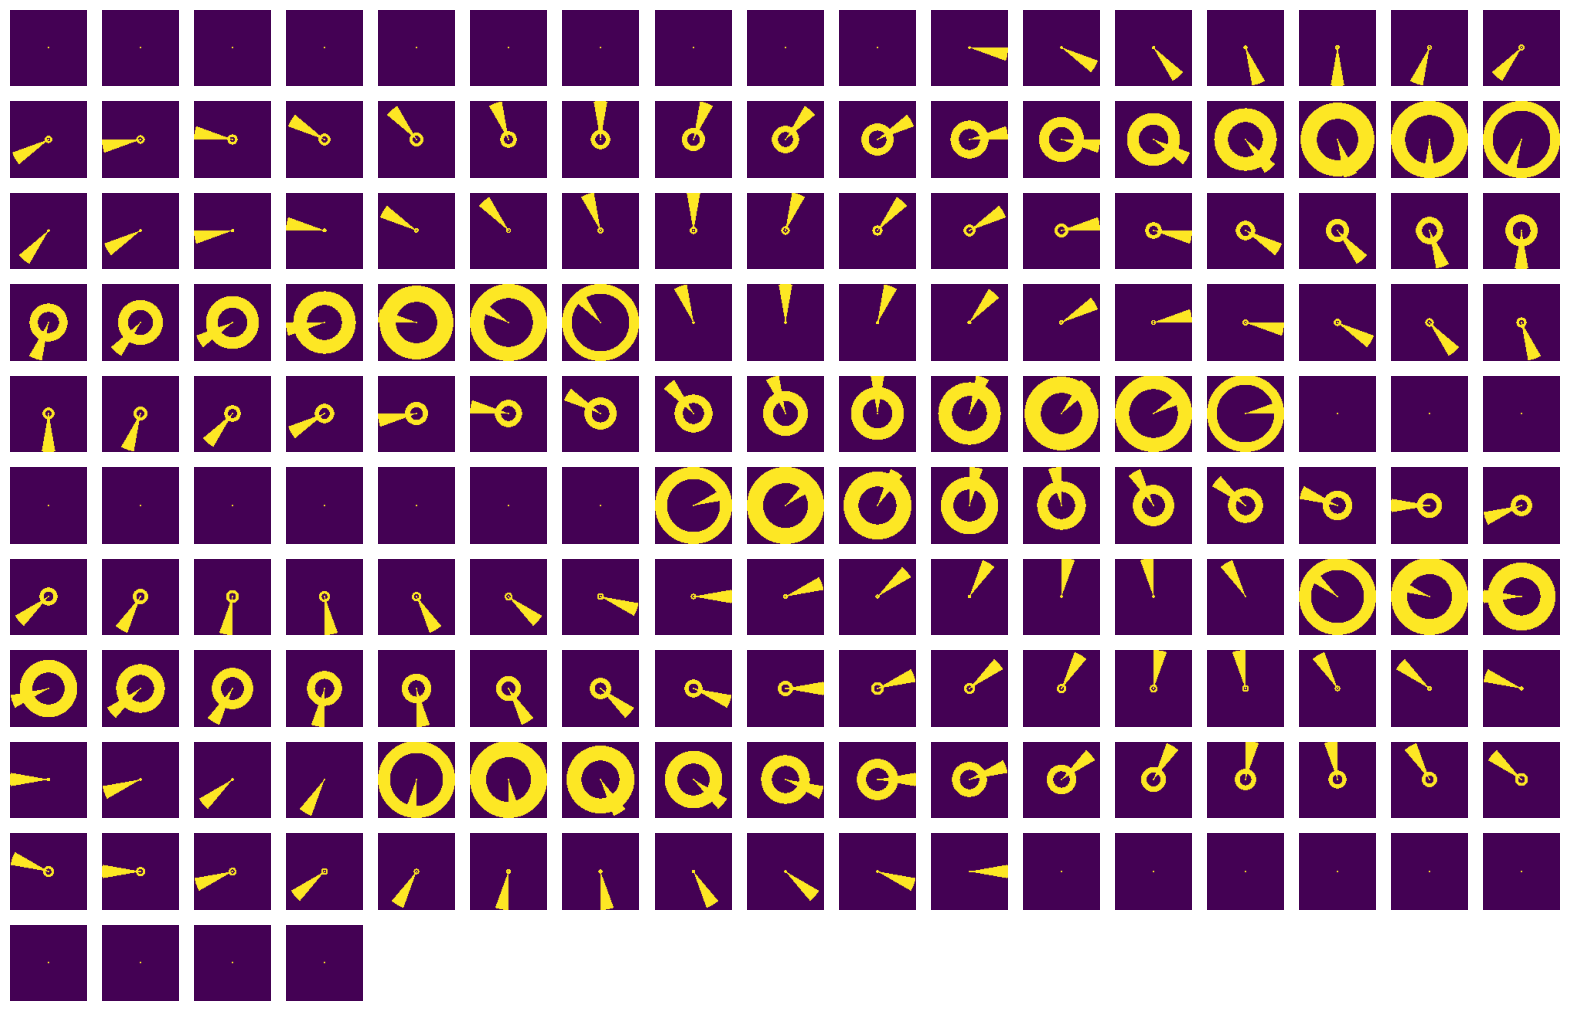

In [5]:
# If you already have the design matrix as a numpy array, you can simply load it...
# again you can change this to your dm
dm = np.load('eg_prf_dm.npy')

# You can see we have a binarized matrix, of a bar moving across the screen...
fig = plt.figure()
rows = 17
cols = 17
fig.set_size_inches(20,20)
for iax,idx in enumerate(range(1,348,2)):
    try:
        ax = fig.add_subplot(rows, cols, iax+1)
    except:
        print(idx)
    ax.imshow(dm[:,:,idx], vmin=0, vmax=1)
    ax.axis('off')


In [6]:
# Now we need to enter the design matrix in a way that prfpy can read it. 
# We do this using the PRFStimulus2D object
# Information we need
# -> Screen size (height), and distance (to the eye)
# This is so that we can convert into degrees of visual angle (dov)
# -> TR: This is so that we know the time (in s), of each 'frame' / pt in the time series
# Here we have 225 time points. So total length of scan was TR * 225 (1.5*225) 
prf_stim = PRFStimulus2D(
    screen_size_cm=prf_settings['screen_size_cm'],          # Distance of screen to eye
    screen_distance_cm=prf_settings['screen_distance_cm'],  # height of the screen (i.e., the diameter of the stimulated region)
    design_matrix=dm,                                   # dm (npix x npix x time_points)
    TR=prf_settings['TR'],                                  # TR
    )
print(f'Screen size in degrees of visual angle = {prf_stim.screen_size_degrees}')

# If for some reason you do not have the original dimensions, but you do have the dov, you can use this calculator:
# https://elvers.us/perception/visualAngle/ to make up some values for screen_size and distance, which will work...


Screen size in degrees of visual angle = 43.311978076844994


In [7]:
prf_settings

{'TR': 1,
 'psc_baseline': 19,
 'vols_to_chop': 4,
 'n_jobs': 4,
 'n_batches': 10,
 'grid_nr': {'ecc': 10, 'pol': 10, 'size': 10, 'hrf_1': 1},
 'normalize_RFs': False,
 'fixed_grid_baseline': None,
 'bold_bsl': [-10, 10],
 'prf_ampl': [0, 1000],
 'rsq_threshold': 0.01,
 'hrf': {'pars': [1, 1, 0], 'deriv_bound': [0, 10], 'disp_bound': [0, 0]},
 'screen_size_cm': 27,
 'screen_distance_cm': 34,
 'eps': '1e-1',
 'filter_predictions': False,
 'norm': {'surround_amplitude_grid': [0.05, 0.2, 0.4, 0.7, 1, 3],
  'surround_size_grid': [5, 8, 12, 18],
  'neural_baseline_grid': [0, 1, 10, 100],
  'surround_baseline_grid': [0.1, 1.0, 10.0, 100.0],
  'surround_amplitude_bound': [0, 1000],
  'neural_baseline_bound': [0, 1000],
  'surround_baseline_bound': [1e-06, 1000]}}

# Loading data
Next we need to load the cortical surface data, and convert it from raw EPI signal across runs, to the mean percent signal change across runs. The following functions do this

In [19]:
# --- names & variables you will have to change ---
input_file = 's4_denoised'
output_file = 's5_prf_testing'
subject = 'sub-hp01'
session = 'ses-01'
task = 'pRFLE'
roi = 'b14_V1V2V3' # Just use the 
# ------ 


bids_dir = os.environ['BIDS_DIR']
fs_dir = opj(bids_dir, 'derivatives', 'freesurfer')
input_dir     = str(Path(
    opj(bids_dir, 'derivatives', input_file)
).resolve())
output_dir   = str(Path(
    opj(bids_dir, 'derivatives', output_file)
).resolve())

subject_input_dir    = opj(input_dir,     subject, session)
subject_output_dir   = opj(output_dir,   subject, session)

os.makedirs(subject_output_dir, exist_ok=True)

print('-' * 55)
print(' Surface data input  : {}'.format(input_dir))
print(' Output      : {}'.format(output_dir))
print(' Subject     : {}'.format(subject))
print(' Session     : {}'.format(session))
print(f' Settings    : {prf_settings}')
print('-' * 55)


-------------------------------------------------------
 Surface data input  : /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/240522NG/hypot/derivatives/s4_denoised
 Output      : /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/240522NG/hypot/derivatives/s5_prf_testing
 Subject     : sub-hp01
 Session     : ses-01
 Settings    : {'TR': 1, 'psc_baseline': 19, 'vols_to_chop': 4, 'n_jobs': 4, 'n_batches': 10, 'grid_nr': {'ecc': 10, 'pol': 10, 'size': 10, 'hrf_1': 1}, 'normalize_RFs': False, 'fixed_grid_baseline': None, 'bold_bsl': [-10, 10], 'prf_ampl': [0, 1000], 'rsq_threshold': 0.01, 'hrf': {'pars': [1, 1, 0], 'deriv_bound': [0, 10], 'disp_bound': [0, 0]}, 'screen_size_cm': 27, 'screen_distance_cm': 34, 'eps': '1e-1', 'filter_predictions': False, 'norm': {'surround_amplitude_grid': [0.05, 0.2, 0.4, 0.7, 1, 3], 'surround_size_grid': [5, 8, 12, 18], 'neural_baseline_grid': [0, 1, 10, 100], 'surround_baseline_grid': [0.1, 1.0, 10.0, 100.0], 'surround_amplitude_bound': [0, 1000], 'n

In [20]:
from s01_gauss_prfpy import *
roi_mask = dpu_load_roi(subject, roi, fs_dir)
roi_idx = np.where(roi_mask)[0]
print(f'Loading roi {roi}, fitting {roi_mask.sum()} vertices')
print(f'(which is {roi_mask.mean()*100:.3f}% of all vertices)')
psc_file = opj(
    subject_input_dir, f'{subject}_{session}_task-{task}_avg-psc.npy')

psc_data = psc_average(
    subject_input_dir   = subject_input_dir,
    psc_file            = psc_file,
    task                = f'task-{task}',
    prf_settings        = prf_settings,
    )
print(f'Chopping data, removing first {prf_settings["vols_to_chop"]}')
psc_data=psc_data[roi_mask,prf_settings["vols_to_chop"]:]
# Check times series are correct shape as the design matrix
assert dm.shape[-1] == psc_data.shape[-1]


Loading roi b14_V1V2V3, fitting 21143 vertices
(which is 7.613% of all vertices)


/Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/240522NG/hypot/code/hypot_code/cvl_utils/cvl_utils/prf_utils.py:194: RuntimeWarning: divide by zero encountered in divide
  psc_factor = np.nan_to_num( 100 / np.mean(ts, axis=t_dim))


Chopping data, removing first 4


# Creating the (gaussian) model
Next up we create the "gaussian" model object. ```prfpy``` is built with an "object oriented style" i.e., functions, settings and data are held together in one structure (rather than having multiple input-output functions)  

In [21]:
'''    
    """__init__ for Iso2DGaussianModel
    constructor, sets up stimulus and hrf for this Model
    Parameters
    ----------
    stimulus : PRFStimulus2D
        Stimulus object specifying the information about the stimulus,
        and the space in which it lives.
    hrf : string, list or numpy.ndarray, optional
        HRF shape for this Model.
        Can be 'direct', which implements nothing (for eCoG or later convolution),
        a list or array of 3, which are multiplied with the three spm HRF basis functions,
        and an array already sampled on the TR by the user.
        (the default is None, which implements standard spm HRF)
    filter_predictions : boolean, optional
        whether to high-pass filter the predictions, default False
    filter_type, filter_params : see timecourse.py
    normalize_RFs : whether or not to normalize the RF volumes (generally not needed).
'''
gmodel = Iso2DGaussianModel(
    stimulus=prf_stim,                                  # The stimulus we made earlier
    hrf=prf_settings['hrf']['pars'],                        # These are the parameters for the HRF that we normally use at Spinoza (with 7T data). (we can fit it, this will be done later...)
    filter_predictions = prf_settings['filter_predictions'],# Do you want to filter the predictions? (depends what you did to the data, try and match it... default is not to do anything)
    normalize_RFs= prf_settings['normalize_RFs'],           # Normalize the volume of the RF (so that RFs w/ different sizes have the same volume. Generally not needed, as this can be solved using the beta values i.e.,amplitude)
    )


A note on the HRF

Generally we only to fit "hrf_1" (i.e., the derivative). The HRF is created using the 3 SPM basis functions, and the 3 hrf parameters determine how this works. We tend to fix hrf_pars[0] to = 1, as parameter can confound with the size and the amplitude of the PRF estimate. Similarly we generally fix hrf_2 (the dispersion) to =0, because it can confound with inhibitory PRF models. It is possible to fix all the HRF parameters (i.e., and use the default) and still get good quality PRF fits.   


We also need to create the gaussian model fitter object

In [22]:
# Load the model fitter
gfit = Iso2DGaussianFitter(
    data=psc_data,                  # time series
    model=gmodel,                   # model (see above)
    n_jobs=prf_settings['n_jobs'],  # number of jobs to use in parallelization 
    )

### Fitting 
Create a grid of possible prf models (different x,y, and size parameters) - and for each vertex, we find the best match. 

We also want to put some boundaries on possible values
We can set the baseline to 0  (```fixed_grid_baseline=0```) or let it have any value (```fixed_grid_baseline=None```)

In addition, there is the amplitude parameter (which scales the response). 

We want to put an upper limit for this too, so that we don't get strange responses

In [23]:

# keys for gauss pars
gaussp_keys = prfpy_params_dict()['gauss']
max_eccentricity = prf_stim.screen_size_degrees/2 # It doesn't make sense to look for PRFs which are outside the stimulated region
grid_nr = prf_settings['grid_nr'] # Size of the grid (i.e., number of possible PRF models). Higher number means that the grid fit will be more exact, but take longer...
eccs    = max_eccentricity * np.linspace(
    0.25, 1, grid_nr['ecc'])**2 # Squared because of cortical magnification, more efficiently tiles the visual field...
sizes   = max_eccentricity * np.linspace(
    0.1, 1, grid_nr['size'])**2  # Possible size values (i.e., sigma in gaussian model) 
polars  = np.linspace(
    0, 2*np.pi, grid_nr['pol'])              # Possible polar angle coordinates

# We can also fit the hrf in the same way (specifically the derivative)
# -> make a grid between 0-10 (see settings file)
if grid_nr['hrf_1'] == 1:
    # Stick to default hrf
    hrf_1_grid = np.array(prf_settings['hrf']['pars'][1])
else:
    hrf_1_grid = np.linspace(
        prf_settings['hrf']['deriv_bound'][0], 
        prf_settings['hrf']['deriv_bound'][1], 
        grid_nr['hrf_1'])
# We generally recommend to fix the dispersion value to 0
hrf_2_grid = np.array([0.0])
# Amplitude bounds for gauss grid fit - set [min, max]
gauss_grid_bounds = [[prf_settings['prf_ampl'][0],prf_settings['prf_ampl'][1]]] 
gauss_bounds = [
    (-1.5*max_eccentricity, 1.5*max_eccentricity),          # x bound
    (-1.5*max_eccentricity, 1.5*max_eccentricity),          # y bound
    (1e-1, max_eccentricity*3),                             # prf size bounds
    (prf_settings['prf_ampl'][0],prf_settings['prf_ampl'][1]),      # prf amplitude
    (prf_settings['bold_bsl'][0],prf_settings['bold_bsl'][1]),      # bold baseline (fixed)
    (prf_settings['hrf']['deriv_bound'][0], prf_settings['hrf']['deriv_bound'][1]), # hrf_1 bound
    (prf_settings['hrf']['disp_bound'][0], prf_settings['hrf']['disp_bound'][1]), # hrf_2 bound
]





In [24]:
# Run the grid fitting 
grid_csv = opj(
    subject_output_dir, 
    f'{subject}_{session}_roi-{roi}_task-{task}_model-gauss_stage-grid.csv')
gfit.grid_fit(
    ecc_grid=eccs,
    polar_grid=polars,
    size_grid=sizes,
    hrf_1_grid=hrf_1_grid,
    hrf_2_grid=hrf_2_grid,
    verbose=True,
    n_batches=prf_settings['n_batches'],               # The grid fit is performed in parallel over n_batches of units.Batch parallelization is faster than single-unit parallelization and of sequential computing.
    
    # Fix the bold baseline? 
    # Optional - generally set to None
    fixed_grid_baseline=prf_settings['fixed_grid_baseline'], 
    grid_bounds=gauss_grid_bounds
    )
# Sometimes the fits are bad and will return NaN values. We do not want this so will remove them here:
gfit.gridsearch_params = filter_for_nans(gfit.gridsearch_params)
gfit.gridsearch_r2 = filter_for_nans(gfit.gridsearch_r2)

grid_dict = {}
grid_dict['index'] = roi_idx
for key in gaussp_keys.keys():
    grid_dict[key] = gfit.gridsearch_params[:,gaussp_keys[key]]
grid_pd = pd.DataFrame(grid_dict)
grid_pars_np = gfit.gridsearch_params

grid_pd.to_csv(grid_csv)

Each batch contains approx. 2115 voxels.


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 out of  10 | elapsed:    2.0s finished


## Gaussian Iterative Fit
Now we can do the iterative fit. This takes the best fitting grid (from the above stage), and iteratively tweaks the parameters until the best fit is founds. 

This takes a quite bit longer than the grid fit. We also need to setup the bounds for all the parameters. 

For me (Mac Air, M4) n-jobs=10; n-vertices=6630; 95 mins

It will be faster on the cluster

In [ ]:
# # OPTIONAL - THIS WILL TAKE A LONGER TIME... (depending on n-jobs & how good your pc is)
# iter_csv = opj(
#     subject_output_dir, 
#     f'{subject}_{session}_roi-{roi}_task-{task}_model-gauss_stage-iter.csv')
# gfit.iterative_fit(
#     rsq_threshold=0.1, #prf_settings['rsq_threshold'],    # Minimum variance explained. Puts a lower bound on the quality of PRF fits. Any fits worse than this are thrown away...     
#     verbose=True,
#     bounds=gauss_bounds,       # Bounds (on parameters)
#     )               
# # Sometimes the fits are bad and will return NaN values. We do not want this so will remove them here:
# gfit.iterative_search_params = filter_for_nans(gfit.iterative_search_params)

# iter_dict = {}
# iter_dict['index'] = roi_idx
# for key in gaussp_keys.keys():
#     iter_dict[key] = gfit.iterative_search_params[:,gaussp_keys[key]]
# iter_pd = pd.DataFrame(iter_dict)
# print(f'Mean r2 = {iter_pd["rsq"].mean():.3f}')
# iter_pd.to_csv(iter_csv) # save it as a csv file

# DONE!

To see how we can plot this, go to ```s02_prf_plotting.ipynb```